# 04 — Manual Quantization
- Learning objective: Understand exactly how quantization changes model weights by manually converting a single layer from floating point to INT8 and tracing the consequences.
- Key concepts: symmetric quantization, scale factors, rounding, clipping, dequantization, quantization error, per-tensor vs. per-channel quantization

## Purpose of this notebook
Notebook 05 will use proper tooling to quantize much larger parts of the model, but that only makes sense if we first understand the underlying math. This notebook is the conceptual center of the project. The goal is not to get the best model here. The goal is to see, with our own eyes, where precision is lost and why that loss affects behavior.

## What we are going to do
We will start small and deliberately avoid quantizing the whole model. Instead, we will isolate a single weight matrix, inspect its floating-point values, and apply a naive INT8 quantization scheme by hand. That means we will:

1. Choose one layer to study.
2. Measure its original weight range and distribution.
3. Compute a scale that maps floating-point values into the INT8 range.
4. Round and clip the values to integers.
5. Dequantize them back into approximate floating-point values.
6. Compare the original and reconstructed weights visually and numerically.
7. Run a small inference test to see whether the output changes in an observable way.

By keeping the scope narrow, we can focus on the mechanism rather than the tooling.

## Conceptual landmark: this is where precision loss actually happens
In earlier notebooks we inspected weights and established a baseline evaluation score, but the weights were still untouched. In this notebook, we will perform the exact step where high-precision values are forced onto a smaller set of representable numbers.

That matters because quantization is not magic compression. It is approximation. Many distinct floating-point values will collapse onto the same integer bucket. Once that happens, some information is gone. The central question is whether the lost information was important enough to change the model's behavior.

## The basic math intuition
A floating-point weight matrix can contain a very wide range of real-valued numbers. INT8 can only represent 256 discrete values. To make the conversion possible, we compress the floating-point range using a scale factor.

The rough idea is:
- large floating-point magnitudes determine the scale
- each weight is divided by that scale
- the result is rounded to the nearest integer
- values outside the allowed range are clipped
- later, we multiply by the scale again to recover an approximation of the original value

That final reconstructed matrix is not identical to the original one. The gap between the original and reconstructed values is the quantization error.

## Why naive manual quantization usually performs worse than real tooling
The approach in this notebook is intentionally simple. Real post-training quantization systems usually do much more, including better calibration, smarter grouping strategies, outlier handling, layer-specific treatment, and kernels designed for efficient low-precision inference.

So if our manual result looks worse than what we eventually get in Notebook 05, that is not a failure. That difference is the lesson. It tells us what the tooling is buying us.

## Questions to keep in mind as we work
As we build this notebook, we should keep asking:

- Which layers look safe to quantize, and which look fragile?
- How much distortion do we introduce just by rounding?
- Do a few outlier weights dominate the scale and reduce effective resolution for the rest?
- Does the weight histogram keep its overall shape after quantization, or does it become visibly blocky?
- Can we already see why per-channel or calibration-aware methods might outperform a single naive scale?

These are not side questions. They are the bridge from raw arithmetic to systems-level intuition.

## What we expect to visualize
This notebook should generate visual evidence, not just numbers. The most important artifacts will be:

- the original weight distribution
- the quantized integer distribution
- the dequantized weight distribution
- an error distribution showing how far values moved
- a small before/after comparison of model outputs or logits

The visuals matter because quantization is easier to understand when we can literally see continuous values collapsing into discrete bins.

## Prediction prompts
Before running any meaningful cell in this notebook, we should pause and make explicit predictions. For example:

- What do we think the weight histogram will look like after INT8 rounding?
- How much reconstruction error do we expect from a single-layer quantization experiment?
- Will a small inference example degrade obviously, subtly, or not at all?
- If we quantize an MoE expert layer versus a more standard projection layer, which do we expect to be more sensitive?

Those predictions are part of the learning objective. They force us to build intuition before the plots answer for us.

## Scope and limits
This notebook is about understanding the mechanism, not claiming final benchmark results. A single manually quantized layer will not tell us everything about whole-model INT8 or INT4 behavior. But it will teach us the important local story: how values are compressed, where error comes from, and why some matrices tolerate approximation better than others.

That local story is the foundation for every later comparison in this project.

## How this connects to the bigger picture
At scale, inference optimization is always about tradeoffs. Lower precision reduces memory traffic and can increase throughput, but only if the model remains useful. Production quantization pipelines are really systems for spending a limited error budget carefully.

This notebook gives us the microscopic view of that tradeoff. Later notebooks will zoom out to the engineering view: calibration datasets, export formats, benchmark tables, and mixed-precision strategies.

## Deliverables for this notebook
By the end of Notebook 04, we should have:

- a clearly documented manual quantization procedure for one layer
- plots showing the original, quantized, and reconstructed values
- a simple quantitative summary of reconstruction error
- a small qualitative or task-level inference comparison
- a short interpretation of what the naive method gets wrong

Those results will set us up to appreciate the stronger methods in Notebook 05.

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
MODEL_ID = "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct"                                                                                                                                    
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"                                                                                                                              
                                                                                                                                                                                            
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)                                                                                                                                         
                                                                                                                                                                                            
model = AutoModelForCausalLM.from_pretrained(                                                                                                                                               
    MODEL_ID,                                                                                                                                                                               
    dtype=torch.float16 if DEVICE == "mps" else torch.float32,                                                                                                                              
    attn_implementation="eager",   # critical: fixes attention shape-path issue                                                                                                             
    device_map=None,                                                                                                                                                                        
)                                                                                                                                                                                           
model.to(DEVICE)                                                                                                                                                                            
model.eval()                                                                                                                                                                                
                                                                                                                                                                                            
# Force MoE implementation to eager too (critical on MPS)                                                                                                                                   
model.config._experts_implementation = "eager"                                                                                                                                              
model.config._attn_implementation = "eager"                                                                                                                                                 
                                                                                                                                                                                            
for layer in model.model.layers:                                                                                                                                                            
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "config"):                                                                                                                              
        layer.mlp.config._experts_implementation = "eager"                                                                                                                                  
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "experts") and hasattr(layer.mlp.experts, "config"):                                                                                    
        layer.mlp.experts.config._experts_implementation = "eager"                                                                                                                          
                                                                                                                                                                                            
# fail-fast sanity check (so Run All fails here, not deep in notebook)                                                                                                                      
_test_inputs = tokenizer("sanity check", return_tensors="pt").to(DEVICE)                                                                                                                    
with torch.no_grad():                                                                                                                                                                       
    _ = model(**_test_inputs).logits[:, -1, :]                                                                                                                                              
print("Model init + forward sanity check OK on", DEVICE)   

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1
`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

Model init + forward sanity check OK on mps


In [3]:
target_layer = model.model.layers[0].mlp.down_proj

w_fp16 = target_layer.weight.detach().to(torch.float16).cpu().clone()

print("Target layer:", target_layer.__class__.__name__)
print("Weight shape:", tuple(w_fp16.shape))
print("Weight dtype:", w_fp16.dtype)

Target layer: Linear
Weight shape: (2048, 10944)
Weight dtype: torch.float16


In [4]:
max_abs = w_fp16.abs().max().item()
scale = max_abs / 127.0 if max_abs > 0 else 1.0

w_int8 = torch.clamp(torch.round(w_fp16 / scale), -127, 127).to(torch.int8)
w_int8_deq = (w_int8.float() * scale).to(torch.float16)

print(f"max_abs: {max_abs:.6f}")
print(f"scale: {scale:.8f}")
print("quant dtype:", w_int8.dtype)
print("dequant dtype:", w_int8_deq.dtype)
print("int8 range:", int(w_int8.min()), "to", int(w_int8.max()))

max_abs: 0.511719
scale: 0.00402928
quant dtype: torch.int8
dequant dtype: torch.float16
int8 range: -121 to 127


In [5]:
err = (w_int8_deq - w_fp16).float()
abs_err = err.abs()

mae = abs_err.mean().item()
rmse = torch.sqrt((err ** 2).mean()).item()
max_abs_err = abs_err.max().item()

denom = w_fp16.float().abs().clamp_min(1e-8)
mre = (abs_err / denom).mean().item()

num_clipped_pos = (torch.round(w_fp16 / scale) > 127).sum().item()
num_clipped_neg = (torch.round(w_fp16 / scale) < -127).sum().item()

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MaxAbsErr: {max_abs_err:.6f}")
print(f"MeanRelErr: {mre:.6f}")
print(f"Clipped +: {num_clipped_pos}")
print(f"Clipped -: {num_clipped_neg}")

MAE: 0.001007
RMSE: 0.001163
MaxAbsErr: 0.002197
MeanRelErr: 0.155549
Clipped +: 0
Clipped -: 0


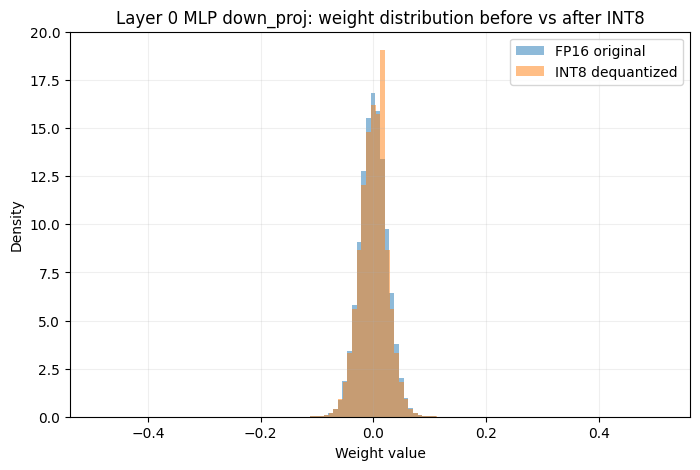

In [6]:
import matplotlib.pyplot as plt

w0 = w_fp16.float().flatten().numpy()
wq = w_int8_deq.float().flatten().numpy()

plt.figure(figsize=(8,5))
plt.hist(w0, bins=120, alpha=0.50, label="FP16 original", density=True)
plt.hist(wq, bins=120, alpha=0.50, label="INT8 dequantized", density=True)
plt.title("Layer 0 MLP down_proj: weight distribution before vs after INT8")
plt.xlabel("Weight value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

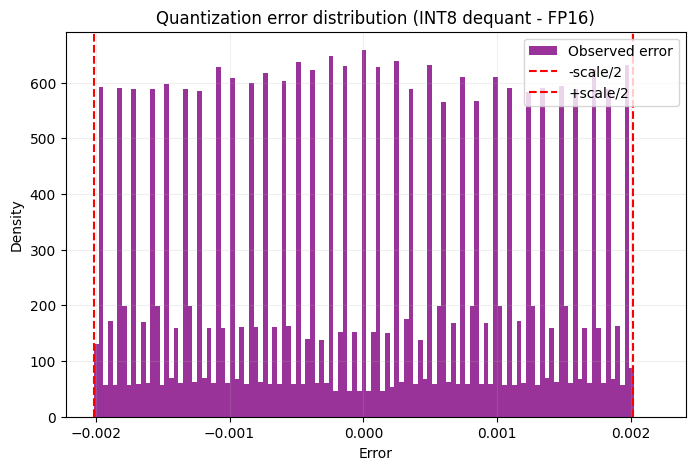

Expected MAE ~ scale/4 = 0.001007
Expected RMSE ~ scale/sqrt(12) = 0.001163


In [7]:
import numpy as np

err = (w_int8_deq.float() - w_fp16.float()).flatten().numpy()                                                                                                       
                                                                                                                                                                    
plt.figure(figsize=(8, 5))                                                                                                                                          
plt.hist(err, bins=120, density=True, alpha=0.8, color="purple", label="Observed error")                                                                            
                                                                                                                                                                    
# Theoretical bounds for rounding error (no clipping): [-scale/2, +scale/2]                                                                                         
half = scale / 2.0                                                                                                                                                  
plt.axvline(-half, color="red", linestyle="--", linewidth=1.5, label="-scale/2")                                                                                    
plt.axvline(+half, color="red", linestyle="--", linewidth=1.5, label="+scale/2")                                                                                    
                                                                                                                                                                    
plt.title("Quantization error distribution (INT8 dequant - FP16)")                                                                                                  
plt.xlabel("Error")                                                                                                                                                 
plt.ylabel("Density")                                                                                                                                               
plt.grid(alpha=0.2)                                                                                                                                                 
plt.legend()                                                                                                                                                        
plt.show()                                                                                                                                                          
                                                                                                                                                                    
print(f"Expected MAE ~ scale/4 = {scale/4:.6f}")                                                                                                                    
print(f"Expected RMSE ~ scale/sqrt(12) = {scale/np.sqrt(12):.6f}")

In [8]:
err = (w_int8_deq.float() - w_fp16.float()).flatten()

uniq, counts = torch.unique(err, return_counts=True)
print("Total weight elements:", err.numel())
print("Unique error values:", uniq.numel())

topk = 12
top_counts, top_idx = torch.topk(counts, k=min(topk, counts.numel()))
print("\nTop repeated error values:")
for c, i in zip(top_counts.tolist(), top_idx.tolist()):
    print(f"error={uniq[i].item(): .7f}, count={c}")

err_np = err.numpy()
print("\nPercentiles of |error|:")
for p in [50, 90, 95, 99, 100]:
    print(f"p{p:>3}: {np.percentile(np.abs(err_np), p):.7f}")

Total weight elements: 22413312
Unique error values: 2314

Top repeated error values:
error= 0.0000000, count=504733
error= 0.0002441, count=485265
error=-0.0002441, count=484906
error= 0.0004883, count=479008
error=-0.0004883, count=477140
error=-0.0009766, count=462937
error= 0.0009766, count=462918
error= 0.0007324, count=462829
error=-0.0007324, count=461831
error=-0.0001221, count=460041
error= 0.0001221, count=457701
error= 0.0014648, count=452461

Percentiles of |error|:
p 50: 0.0009766
p 90: 0.0018311
p 95: 0.0019531
p 99: 0.0019684
p100: 0.0021973


In [9]:
import torch                                                                                                                                                        
import pandas as pd                                                                                                                                                 
                                                                                                                                                                    
rows = []                                                                                                                                                           
                                                                                                                                                                    
for layer_idx, layer in enumerate(model.model.layers):                                                                                                              
    for subname, mod in layer.mlp.named_modules():                                                                                                                  
        if not subname.endswith("down_proj"):                                                                                                                       
            continue                                                                                                                                                
        if not hasattr(mod, "weight"):                                                                                                                              
            continue                                                                                                                                                
                                                                                                                                                                    
        w_fp16 = mod.weight.detach().to(torch.float16).cpu()                                                                                                        
                                                                                                                                                                    
        max_abs = w_fp16.abs().max().item()                                                                                                                         
        scale = max_abs / 127.0 if max_abs > 0 else 1.0                                                                                                             
                                                                                                                                                                    
        q = torch.clamp(torch.round(w_fp16 / scale), -127, 127).to(torch.int8)                                                                                      
        w_deq = (q.float() * scale).to(torch.float16)                                                                                                               
                                                                                                                                                                    
        err = (w_deq - w_fp16).float()                                                                                                                              
        abs_err = err.abs()                                                                                                                                         
                                                                                                                                                                    
        rows.append({                                                                                                                                               
            "layer": layer_idx,                                                                                                                                     
            "module": subname,   # e.g. experts.3.down_proj                                                                                                         
            "shape": tuple(w_fp16.shape),                                                                                                                           
            "max_abs": max_abs,                                                                                                                                     
            "scale": scale,                                                                                                                                         
            "mae": abs_err.mean().item(),                                                                                                                           
            "rmse": torch.sqrt((err ** 2).mean()).item(),                                                                                                           
            "max_abs_err": abs_err.max().item(),                                                                                                                    
            "clip_pos": (torch.round(w_fp16 / scale) > 127).sum().item(),                                                                                           
            "clip_neg": (torch.round(w_fp16 / scale) < -127).sum().item(),                                                                                          
        })                                                                                                                                                          
                                                                                                                                                                    
df_moe_down = pd.DataFrame(rows).sort_values("mae", ascending=False).reset_index(drop=True)                                                                         
                                                                                                                                                                    
print("Total down_proj tensors found:", len(df_moe_down))                                                                                                           
print(df_moe_down.head(10))   

Total down_proj tensors found: 27
   layer                    module         shape   max_abs     scale  \
0     24  shared_experts.down_proj  (2048, 2816)  1.140625  0.008981   
1     12  shared_experts.down_proj  (2048, 2816)  0.925781  0.007290   
2     18  shared_experts.down_proj  (2048, 2816)  0.890625  0.007013   
3     26  shared_experts.down_proj  (2048, 2816)  0.878906  0.006921   
4     23  shared_experts.down_proj  (2048, 2816)  0.875000  0.006890   
5     14  shared_experts.down_proj  (2048, 2816)  0.832031  0.006551   
6      7  shared_experts.down_proj  (2048, 2816)  0.812500  0.006398   
7     11  shared_experts.down_proj  (2048, 2816)  0.808594  0.006367   
8     15  shared_experts.down_proj  (2048, 2816)  0.808594  0.006367   
9      5  shared_experts.down_proj  (2048, 2816)  0.781250  0.006152   

        mae      rmse  max_abs_err  clip_pos  clip_neg  
0  0.002244  0.002592     0.004517         0         0  
1  0.001822  0.002104     0.003662         0         0  
2 

In [10]:
# 1) How many module patterns did we actually capture?                                                                                                              
print("Unique module names:")                                                                                                                                       
print(df_moe_down["module"].value_counts())                                                                                                                         
                                                                                                                                                                    
# 2) Check the key quantization sanity ratio: MAE / scale (should be near ~0.25 for naive rounding)                                                                 
tmp = df_moe_down.copy()                                                                                                                                            
tmp["mae_over_scale"] = tmp["mae"] / tmp["scale"]                                                                                                                   
print("\nMAE/scale summary:")                                                                                                                                       
print(tmp["mae_over_scale"].describe())                                                                                                                             
                                                                                                                                                                    
# 3) Show layers with largest MAE                                                                                                                                   
print("\nTop layers by MAE:")                                                                                                                                       
print(tmp.sort_values("mae", ascending=False)[["layer", "module", "scale", "mae", "rmse"]].head(15)) 

Unique module names:
module
shared_experts.down_proj    26
down_proj                    1
Name: count, dtype: int64

MAE/scale summary:
count    27.000000
mean      0.250001
std       0.000089
min       0.249846
25%       0.249936
50%       0.249986
75%       0.250068
max       0.250170
Name: mae_over_scale, dtype: float64

Top layers by MAE:
    layer                    module     scale       mae      rmse
0      24  shared_experts.down_proj  0.008981  0.002244  0.002592
1      12  shared_experts.down_proj  0.007290  0.001822  0.002104
2      18  shared_experts.down_proj  0.007013  0.001753  0.002024
3      26  shared_experts.down_proj  0.006921  0.001730  0.001998
4      23  shared_experts.down_proj  0.006890  0.001722  0.001989
5      14  shared_experts.down_proj  0.006551  0.001637  0.001891
6       7  shared_experts.down_proj  0.006398  0.001600  0.001847
7      11  shared_experts.down_proj  0.006367  0.001592  0.001838
8      15  shared_experts.down_proj  0.006367  0.001591  0.00

In [11]:
rows_pc = []

for layer_idx, layer in enumerate(model.model.layers):
    for subname, mod in layer.mlp.named_modules():
        if not subname.endswith("down_proj") or not hasattr(mod, "weight"):
            continue

        w = mod.weight.detach().to(torch.float16).cpu()    # [out_features, in_features]

        s_t = w.abs().max().item() / 127.0 if w.abs().max().item() > 0 else 1.0
        q_t = torch.clamp(torch.round(w / s_t), -127, 127).to(torch.int8)
        w_t = (q_t.float() * s_t).to(torch.float16)
        mae_t = (w_t - w).abs().float().mean().item()

        max_abs_row = w.abs().amax(dim=1, keepdim=True).float()      # [out, 1]
        s_c = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))
        q_c = torch.clamp(torch.round(w.float() / s_c), -127, 127).to(torch.int8)
        w_c = (q_c.float() * s_c).to(torch.float16)
        mae_c = (w_c - w).abs().float().mean().item()

        rows_pc.append({
            "layer": layer_idx,
            "module": subname,
            "mae_per_tensor": mae_t,
            "mae_per_channel": mae_c,
            "improvement_pct": 100.0 * (mae_t - mae_c) / (mae_t + 1e-12),
        })

df_pc = pd.DataFrame(rows_pc)
print(df_pc[["mae_per_tensor", "mae_per_channel", "improvement_pct"]].describe())
print("\nTop 10 biggest per-channel gains:")
print(df_pc.sort_values("improvement_pct", ascending=False).head(10))

       mae_per_tensor  mae_per_channel  improvement_pct
count       27.000000        27.000000        27.000000
mean         0.001415         0.000132        90.282829
std          0.000307         0.000026         3.058841
min          0.000962         0.000083        77.419714
25%          0.001165         0.000117        89.681029
50%          0.001477         0.000130        90.938743
75%          0.001596         0.000143        92.091767
max          0.002244         0.000227        93.221639

Top 10 biggest per-channel gains:
    layer                    module  mae_per_tensor  mae_per_channel  \
14     14  shared_experts.down_proj        0.001637         0.000111   
24     24  shared_experts.down_proj        0.002244         0.000157   
15     15  shared_experts.down_proj        0.001591         0.000112   
26     26  shared_experts.down_proj        0.001730         0.000123   
5       5  shared_experts.down_proj        0.001538         0.000117   
16     16  shared_experts.dow

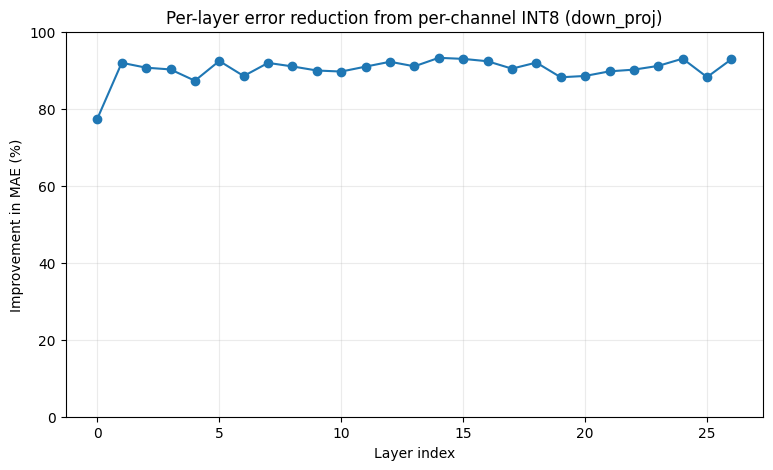

Improvement summary (%):
count    27.000000
mean     90.282829
std       3.058841
min      77.419714
25%      89.681029
50%      90.938743
75%      92.091767
max      93.221639
Name: improvement_pct, dtype: float64


In [12]:
import matplotlib.pyplot as plt

plot_df = df_pc.sort_values(["layer", "module"]).reset_index(drop=True)

plt.figure(figsize=(9,5))
plt.plot(plot_df["layer"], plot_df["improvement_pct"], marker="o", linewidth=1.5)
plt.title("Per-layer error reduction from per-channel INT8 (down_proj)")
plt.xlabel("Layer index")
plt.ylabel("Improvement in MAE (%)")
plt.grid(alpha=0.25)
plt.ylim(0,100)
plt.show()

print("Improvement summary (%):")
print(plot_df["improvement_pct"].describe())

In [13]:
import torch
import pandas as pd

rows_up = []

for layer_idx, layer in enumerate(model.model.layers):
    for subname, mod in layer.mlp.named_modules():
        if not subname.endswith("up_proj") or not hasattr(mod, "weight"):
            continue

        w = mod.weight.detach().to(torch.float16).cpu()

        # per-tensor
        s_t = w.abs().max().item() / 127.0 if w.abs().max().item() > 0 else 1.0
        q_t = torch.clamp(torch.round(w / s_t), -127, 127).to(torch.int8)
        w_t = (q_t.float() * s_t).to(torch.float16)
        mae_t = (w_t - w).abs().float().mean().item()

        # per-channel (row-wise)
        max_abs_row = w.abs().amax(dim=1, keepdim=True).float()
        s_c = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))
        q_c = torch.clamp(torch.round(w.float() / s_c), -127, 127).to(torch.int8)
        w_c = (q_c.float() * s_c).to(torch.float16)
        mae_c = (w_c - w).abs().float().mean().item()

        rows_up.append({
            "layer": layer_idx,
            "module": subname,
            "mae_per_tensor": mae_t,
            "mae_per_channel": mae_c,
            "improvement_pct": 100.0 * (mae_t - mae_c) / (mae_t + 1e-12),
        })

df_up = pd.DataFrame(rows_up)
print(df_up[["mae_per_tensor", "mae_per_channel", "improvement_pct"]].describe())

       mae_per_tensor  mae_per_channel  improvement_pct
count       27.000000        27.000000        27.000000
mean         0.000850         0.000107        86.898885
std          0.000205         0.000021         3.292205
min          0.000491         0.000053        76.096042
25%          0.000736         0.000103        85.630329
50%          0.000815         0.000107        87.560428
75%          0.000977         0.000113        88.711397
max          0.001361         0.000187        91.537764


In [14]:
import torch                                                                                                                                                        
import pandas as pd                                                                                                                                                 
                                                                                                                                                                    
rows_gate = []                                                                                                                                                      
                                                                                                                                                                    
for layer_idx, layer in enumerate(model.model.layers):                                                                                                              
    for subname, mod in layer.mlp.named_modules():                                                                                                                  
        if not subname.endswith("gate_proj") or not hasattr(mod, "weight"):                                                                                         
            continue                                                                                                                                                
                                                                                                                                                                    
        w = mod.weight.detach().to(torch.float16).cpu()                                                                                                             
                                                                                                                                                                    
        # per-tensor                                                                                                                                                
        s_t = w.abs().max().item() / 127.0 if w.abs().max().item() > 0 else 1.0                                                                                     
        q_t = torch.clamp(torch.round(w / s_t), -127, 127).to(torch.int8)                                                                                           
        w_t = (q_t.float() * s_t).to(torch.float16)                                                                                                                 
        mae_t = (w_t - w).abs().float().mean().item()                                                                                                               
                                                                                                                                                                    
        # per-channel (row-wise)                                                                                                                                    
        max_abs_row = w.abs().amax(dim=1, keepdim=True).float()                                                                                                     
        s_c = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))                                                                       
        q_c = torch.clamp(torch.round(w.float() / s_c), -127, 127).to(torch.int8)                                                                                   
        w_c = (q_c.float() * s_c).to(torch.float16)                                                                                                                 
        mae_c = (w_c - w).abs().float().mean().item()                                                                                                               
                                                                                                                                                                    
        rows_gate.append({                                                                                                                                          
            "layer": layer_idx,                                                                                                                                     
            "module": subname,                                                                                                                                      
            "mae_per_tensor": mae_t,                                                                                                                                
            "mae_per_channel": mae_c,                                                                                                                               
            "improvement_pct": 100.0 * (mae_t - mae_c) / (mae_t + 1e-12),                                                                                           
        })                                                                                                                                                          
                                                                                                                                                                    
df_gate = pd.DataFrame(rows_gate)                                                                                                                                   
print(df_gate[["mae_per_tensor", "mae_per_channel", "improvement_pct"]].describe())  

       mae_per_tensor  mae_per_channel  improvement_pct
count       27.000000        27.000000        27.000000
mean         0.000887         0.000153        81.312471
std          0.000183         0.000049         9.164024
min          0.000463         0.000065        59.783129
25%          0.000789         0.000119        72.346945
50%          0.000896         0.000133        85.260734
75%          0.001027         0.000187        88.097913
max          0.001230         0.000243        93.002397


In [15]:
import torch                                                                                                                                                                                
import torch.nn.functional as F                                                                                                                                                             
import pandas as pd                                                                                                                                                                         
                                                                                                                                                                                            
# Ensure stable forward path for this notebook (Run All safe)                                                                                                                               
model.config._experts_implementation = "eager"                                                                                                                                              
for layer in model.model.layers:                                                                                                                                                            
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "config"):                                                                                                                              
        layer.mlp.config._experts_implementation = "eager"                                                                                                                                  
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "experts") and hasattr(layer.mlp.experts, "config"):                                                                                    
        layer.mlp.experts.config._experts_implementation = "eager"                                                                                                                          
                                                                                                                                                                                            
mod_name = "shared_experts.down_proj"                                                                                                                                                       
                                                                                                                                                                                            
prompt = "Write a Python function that checks if a string is a palindrome."                                                                                                                 
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)                                                                                                                                  
                                                                                                                                                                                            
# Baseline once (outside loop)                                                                                                                                                              
with torch.no_grad():                                                                                                                                                                       
    base_logits = model(**inputs).logits[:, -1, :].float().cpu()                                                                                                                            
                                                                                                                                                                                            
rows = []                                                                                                                                                                                   
                                                                                                                                                                                            
for layer_idx, layer in enumerate(model.model.layers[1:], start=1):                                                                                                                         
    target = dict(layer.mlp.named_modules())[mod_name]                                                                                                                                      
    w_orig = target.weight.detach().clone()                                                                                                                                                 
                                                                                                                                                                                            
    try:                                                                                                                                                                                    
        w = w_orig.detach().to(torch.float16).cpu()                                                                                                                                         
                                                                                                                                                                                            
        # --- per-tensor quantization ---                                                                                                                                                   
        s_t = w.abs().max().item() / 127.0 if w.abs().max().item() > 0 else 1.0                                                                                                             
        q_t = torch.clamp(torch.round(w / s_t), -127, 127).to(torch.int8)                                                                                                                   
        w_t = (q_t.float() * s_t).to(torch.float16).to(w_orig.device)                                                                                                                       
                                                                                                                                                                                            
        with torch.no_grad():                                                                                                                                                               
            target.weight.copy_(w_t)                                                                                                                                                        
            logits_t = model(**inputs).logits[:, -1, :].float().cpu()                                                                                                                       
                                                                                                                                                                                            
        # --- per-channel quantization (row-wise) ---                                                                                                                                       
        max_abs_row = w.abs().amax(dim=1, keepdim=True).float()                                                                                                                             
        s_c = torch.where(max_abs_row > 0, max_abs_row / 127.0, torch.ones_like(max_abs_row))                                                                                               
        q_c = torch.clamp(torch.round(w.float() / s_c), -127, 127).to(torch.int8)                                                                                                           
        w_c = (q_c.float() * s_c).to(torch.float16).to(w_orig.device)                                                                                                                       
                                                                                                                                                                                            
        with torch.no_grad():                                                                                                                                                               
            target.weight.copy_(w_c)                                                                                                                                                        
            logits_c = model(**inputs).logits[:, -1, :].float().cpu()                                                                                                                       
                                                                                                                                                                                            
    finally:                                                                                                                                                                                
        # Always restore original weights                                                                                                                                                   
        with torch.no_grad():                                                                                                                                                               
            target.weight.copy_(w_orig)                                                                                                                                                     
                                                                                                                                                                                            
    # Metrics                                                                                                                                                                               
    d_t = base_logits - logits_t                                                                                                                                                            
    d_c = base_logits - logits_c                                                                                                                                                            
                                                                                                                                                                                            
    mse_t = torch.mean(d_t * d_t).item()                                                                                                                                                    
    mse_c = torch.mean(d_c * d_c).item()                                                                                                                                                    
    maxabs_t = torch.max(torch.abs(d_t)).item()                                                                                                                                             
    maxabs_c = torch.max(torch.abs(d_c)).item()                                                                                                                                             
    cos_t = F.cosine_similarity(base_logits, logits_t).item()                                                                                                                               
    cos_c = F.cosine_similarity(base_logits, logits_c).item()                                                                                                                               
                                                                                                                                                                                            
    rows.append({                                                                                                                                                                           
        "layer": layer_idx,                                                                                                                                                                 
        "mse_t": mse_t,                                                                                                                                                                     
        "mse_c": mse_c,                                                                                                                                                                     
        "maxabs_t": maxabs_t,                                                                                                                                                               
        "maxabs_c": maxabs_c,                                                                                                                                                               
        "cos_t": cos_t,                                                                                                                                                                     
        "cos_c": cos_c,                                                                                                                                                                     
    })                                                                                                                                                                                      
                                                                                                                                                                                            
df = pd.DataFrame(rows).sort_values("layer").reset_index(drop=True)                                                                                                                         
df["mse_reduction_x"] = df["mse_t"] / (df["mse_c"] + 1e-12)                                                                                                                                 
df["maxabs_reduction_x"] = df["maxabs_t"] / (df["maxabs_c"] + 1e-12)                                                                                                                        
df["cos_gain"] = df["cos_c"] - df["cos_t"]                                                                                                                                                  
                                                                                                                                                                                            
print(df[["mse_reduction_x", "maxabs_reduction_x", "cos_gain"]].describe())                                                                                                                 
print("\nTop layers by MSE reduction:")                                                                                                                                                     
print(df.sort_values("mse_reduction_x", ascending=False).head(8)[                                                                                                                           
    ["layer", "mse_t", "mse_c", "mse_reduction_x", "maxabs_t", "maxabs_c", "cos_t", "cos_c"]                                                                                                
])                                                                                                                                                                                          

       mse_reduction_x  maxabs_reduction_x   cos_gain
count        26.000000           26.000000  26.000000
mean        139.111095            6.861453   0.000165
std         280.618598            5.414187   0.000334
min           2.701243            1.660377   0.000012
25%          14.294737            4.000000   0.000019
50%          31.237064            4.889757   0.000030
75%          76.986554            7.359375   0.000076
max        1090.103328           23.333333   0.001406

Top layers by MSE reduction:
    layer     mse_t     mse_c  mse_reduction_x  maxabs_t  maxabs_c     cos_t  \
12     13  0.046773  0.000043      1090.103328  0.822266  0.046875  0.999093   
2       3  0.027559  0.000033       828.365323  0.789062  0.039062  0.999318   
6       7  0.081639  0.000115       711.234163  1.093750  0.046875  0.998585   
23     24  0.009320  0.000049       191.851097  0.359375  0.039062  0.999809   
8       9  0.005025  0.000037       136.676958  0.220703  0.031250  0.999893   
25  

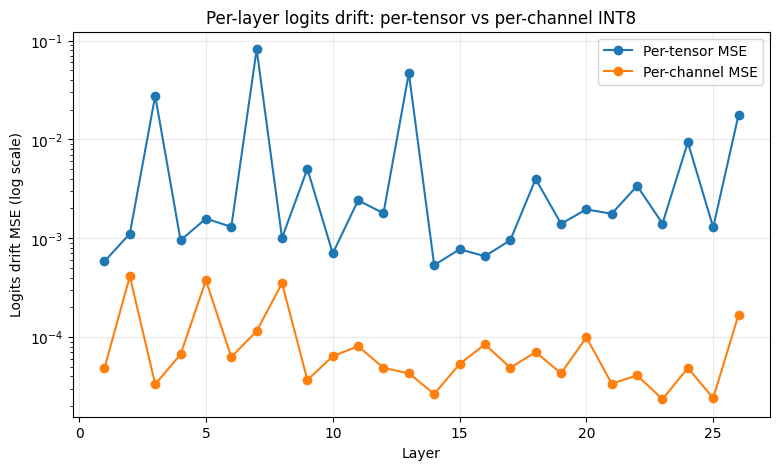

In [16]:
import matplotlib.pyplot as plt                                                                                                                                                             
                                                                                                                                                                                            
plt.figure(figsize=(9,5))                                                                                                                                                                   
plt.plot(df["layer"], df["mse_t"], marker="o", label="Per-tensor MSE")                                                                                                                      
plt.plot(df["layer"], df["mse_c"], marker="o", label="Per-channel MSE")                                                                                                                     
plt.yscale("log")                                                                                                                                                                           
plt.xlabel("Layer")                                                                                                                                                                         
plt.ylabel("Logits drift MSE (log scale)")                                                                                                                                                  
plt.title("Per-layer logits drift: per-tensor vs per-channel INT8")                                                                                                                         
plt.grid(alpha=0.25)                                                                                                                                                                        
plt.legend()                                                                                                                                                                                
plt.show()     

# Conclusion
Across 26 shared-expert down_proj layers, row-wise per-channel INT8 consistently reduced logits drift versus naive per-tensor INT8. Median MSE reduction was 31.2x (IQR: 14.3x–77.0x), with all layers improved (min 2.7x). The largest per-tensor fragility spikes (layers 3, 7, 13, 24, 26) were strongly suppressed (up to 1090x reduction). Max-absolute logit error improved by a median 4.9x. Cosine similarity gains were uniformly positive but numerically small due to already-high baseline cosine values. This indicates that quantization granularity (per-channel vs per-tensor) is a dominant stability factor in this manual INT8 setting.

In [17]:
import os                                                                                                                                                           
import json                                                                                                                                                         
from datetime import datetime, timezone                                                                                                                             
                                                                                                                                                                    
import numpy as np                                                                                                                                                  
import pandas as pd                                                                                                                                                 
                                                                                                                                                                    
os.makedirs("../results", exist_ok=True)                                                                                                                            
                                                                                                                                                                    
def _safe_float(x):                                                                                                                                                 
    try:                                                                                                                                                            
        return float(x)                                                                                                                                             
    except Exception:                                                                                                                                               
        return None                                                                                                                                                 
                                                                                                                                                                    
def summarize_series(s: pd.Series):                                                                                                                                 
    s = pd.to_numeric(s, errors="coerce").dropna()                                                                                                                  
    if len(s) == 0:                                                                                                                                                 
        return {}                                                                                                                                                   
    return {                                                                                                                                                        
        "count": int(s.count()),                                                                                                                                    
        "mean": _safe_float(s.mean()),                                                                                                                              
        "std": _safe_float(s.std(ddof=1)),                                                                                                                          
        "min": _safe_float(s.min()),                                                                                                                                
        "p25": _safe_float(s.quantile(0.25)),                                                                                                                       
        "p50": _safe_float(s.quantile(0.50)),                                                                                                                       
        "p75": _safe_float(s.quantile(0.75)),                                                                                                                       
        "max": _safe_float(s.max()),                                                                                                                                
    }                                                                                                                                                               
                                                                                                                                                                    
def summarize_improvement(df_mod: pd.DataFrame, name: str):                                                                                                         
    out = {"module_group": name}                                                                                                                                    
    if df_mod is None or len(df_mod) == 0:                                                                                                                          
        out["available"] = False                                                                                                                                    
        return out                                                                                                                                                  
                                                                                                                                                                    
    out["available"] = True                                                                                                                                         
    for col in ["mae_per_tensor", "mae_per_channel", "improvement_pct"]:                                                                                            
        if col in df_mod.columns:                                                                                                                                   
            out[f"{col}_summary"] = summarize_series(df_mod[col])                                                                                                   
                                                                                                                                                                    
    if "improvement_pct" in df_mod.columns:                                                                                                                         
        out["top_5_improvement_layers"] = (                                                                                                                         
            df_mod.sort_values("improvement_pct", ascending=False)                                                                                                  
                    .head(5)[["layer", "module", "improvement_pct", "mae_per_tensor", "mae_per_channel"]]                                                             
                    .to_dict(orient="records")                                                                                                                        
        )                                                                                                                                                           
    return out                                                                                                                                                      
                                                                                                                                                                    
# ----- Build results payload -----                                                                                                                                 
results_payload = {                                                                                                                                                 
    "notebook": "04_manual_quantization",                                                                                                                           
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),                                                                                                        
    "metadata": {                                                                                                                                                   
        "model_id": getattr(model, "name_or_path", None) if "model" in globals() else None,                                                                         
        "tokenizer_id": getattr(tokenizer, "name_or_path", None) if "tokenizer" in globals() else None,                                                             
        "device": DEVICE if "DEVICE" in globals() else None,                                                                                                        
        "int8_scheme": {                                                                                                                                            
            "type": "symmetric",                                                                                                                                    
            "int_range_used": [-127, 127],                                                                                                                          
            "per_tensor_scale": "single global scale per weight matrix",                                                                                            
            "per_channel_scale": "row-wise (output-channel-wise) scale"                                                                                             
        },                                                                                                                                                          
    },                                                                                                                                                              
    "single_layer_demo": {},                                                                                                                                        
    "layerwise_weight_error": {},                                                                                                                                   
    "per_channel_vs_per_tensor": {},                                                                                                                                
    "logits_drift": {},                                                                                                                                             
}                                                                                                                                                                   
                                                                                                                                                                    
# 1) Single-layer demo (from early cells)                                                                                                                           
if "max_abs" in globals() and "scale" in globals() and "mae" in globals():                                                                                          
    results_payload["single_layer_demo"] = {                                                                                                                        
        "target_layer": "layer0.mlp.down_proj",                                                                                                                     
        "weight_shape": list(w_fp16.shape) if "w_fp16" in globals() else None,                                                                                      
        "max_abs": _safe_float(max_abs),                                                                                                                            
        "scale": _safe_float(scale),                                                                                                                                
        "mae": _safe_float(mae),                                                                                                                                    
        "rmse": _safe_float(rmse) if "rmse" in globals() else None,                                                                                                 
        "max_abs_err": _safe_float(max_abs_err) if "max_abs_err" in globals() else None,                                                                            
        "mean_rel_err": _safe_float(mre) if "mre" in globals() else None,                                                                                           
    }                                                                                                                                                               
                                                                                                                                                                    
# 2) Layerwise naive per-tensor down_proj error                                                                                                                     
if "df_moe_down" in globals() and isinstance(df_moe_down, pd.DataFrame):                                                                                            
    lw = df_moe_down.copy()                                                                                                                                         
    section = {                                                                                                                                                     
        "n_tensors": int(len(lw)),                                                                                                                                  
        "module_counts": lw["module"].value_counts().to_dict() if "module" in lw.columns else {},                                                                   
        "mae_summary": summarize_series(lw["mae"]) if "mae" in lw.columns else {},                                                                                  
        "rmse_summary": summarize_series(lw["rmse"]) if "rmse" in lw.columns else {},                                                                               
        "scale_summary": summarize_series(lw["scale"]) if "scale" in lw.columns else {},                                                                            
        "top_10_by_mae": lw.sort_values("mae", ascending=False).head(10).to_dict(orient="records") if "mae" in lw.columns else [],                                  
    }                                                                                                                                                               
    if "mae" in lw.columns and "scale" in lw.columns:                                                                                                               
        ratio = lw["mae"] / lw["scale"]                                                                                                                             
        section["mae_over_scale_summary"] = summarize_series(ratio)                                                                                                 
    results_payload["layerwise_weight_error"] = section                                                                                                             
                                                                                                                                                                    
# 3) Per-channel vs per-tensor (weight-space)                                                                                                                       
results_payload["per_channel_vs_per_tensor"] = {                                                                                                                    
    "down_proj": summarize_improvement(df_pc if "df_pc" in globals() else None, "down_proj"),                                                                       
    "up_proj": summarize_improvement(df_up if "df_up" in globals() else None, "up_proj"),                                                                           
    "gate_proj": summarize_improvement(df_gate if "df_gate" in globals() else None, "gate_proj"),                                                                   
}                                                                                                                                                                   
                                                                                                                                                                    
# 4) Logits drift section                                                                                                                                           
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:                                                                                              
    ld = df.copy()                                                                                                                                                  
    drift_section = {                                                                                                                                               
        "n_layers_evaluated": int(len(ld)),                                                                                                                         
        "mse_reduction_x_summary": summarize_series(ld["mse_reduction_x"]) if "mse_reduction_x" in ld.columns else {},                                              
        "maxabs_reduction_x_summary": summarize_series(ld["maxabs_reduction_x"]) if "maxabs_reduction_x" in ld.columns else {},                                     
        "cos_gain_summary": summarize_series(ld["cos_gain"]) if "cos_gain" in ld.columns else {},                                                                   
        "top_8_layers_by_mse_reduction": (                                                                                                                          
            ld.sort_values("mse_reduction_x", ascending=False)                                                                                                      
                .head(8)[["layer", "mse_t", "mse_c", "mse_reduction_x", "maxabs_t", "maxabs_c", "cos_t", "cos_c"]]                                                    
                .to_dict(orient="records")                                                                                                                            
            if "mse_reduction_x" in ld.columns else []                                                                                                              
        ),                                                                                                                                                          
    }                                                                                                                                                               
    results_payload["logits_drift"] = drift_section                                                                                                                 
                                                                                                                                                                    
# Optional: concise conclusions auto-filled from current data                                                                                                       
conclusions = []                                                                                                                                                    
try:                                                                                                                                                                
    med = ld["mse_reduction_x"].median()                                                                                                                            
    q1 = ld["mse_reduction_x"].quantile(0.25)                                                                                                                       
    q3 = ld["mse_reduction_x"].quantile(0.75)                                                                                                                       
    conclusions.append(                                                                                                                                             
        f"Per-channel INT8 reduced logits MSE vs per-tensor across all tested layers; median reduction {med:.2f}x (IQR {q1:.2f}x–{q3:.2f}x)."                       
    )                                                                                                                                                               
except Exception:                                                                                                                                                   
    pass                                                                                                                                                            
                                                                                                                                                                    
try:                                                                                                                                                                
    dmed = df_pc["improvement_pct"].median()                                                                                                                        
    conclusions.append(f"Down-proj weight-space MAE improvement median: {dmed:.2f}% with per-channel scaling.")                                                     
except Exception:                                                                                                                                                   
    pass                                                                                                                                                            
                                                                                                                                                                    
results_payload["conclusions"] = conclusions                                                                                                                        
                                                                                                                                                                    
# ----- Save -----                                                                                                                                                  
out_path = "../results/04_manual_quantization.json"                                                                                                                 
with open(out_path, "w") as f:                                                                                                                                      
    json.dump(results_payload, f, indent=2)                                                                                                                         
                                                                                                                                                                    
print(f"Saved: {out_path}") 

Saved: ../results/04_manual_quantization.json
